In [27]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

In [20]:
tf.version.VERSION

'2.8.0'

In [21]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "use_these_images"

In [22]:
# Funktion zum Einlesen der Bilder und Labels
def load_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          # label = filename.split('_')[1].split(".")[0]
          label = filename.split("_")[4].split(".")[0]
        else:
          continue

        label = float(label)

        img = cv2.imread(os.path.join(directory, filename))
        img = cv2.resize(img, IMAGE_SIZE)
        img = img / 255.0

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

In [35]:
def plot_train_history(history):
  plt.plot(history.history['loss'], color='blue')
  plt.plot(history.history['val_loss'], color='red')
  plt.legend(["training loss", "validation loss"])

In [23]:
# Bilder und Labels laden
images, labels = load_images_from_directory(IMAGE_DIRECTORY)

labels

array([ 97., 103., 114., 117.,  57.,  54., 120., 113., 126., 132.,  88.,
        77.,  63.,  75.,  60.,  53., 129., 125.])

In [24]:
print(images.shape)
print(labels)

(18, 128, 128, 3)
[ 97. 103. 114. 117.  57.  54. 120. 113. 126. 132.  88.  77.  63.  75.
  60.  53. 129. 125.]


In [47]:
# Durchschnitt der Labelwerte
np.mean(labels)

94.61111111111111

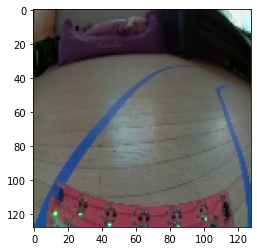

In [25]:
plt.imshow(images[0][:,:,::-1])

In [28]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

In [29]:
 # Modell für Regression kompilieren
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 57600)             0         
                                                                 
 dense (Dense)               (None, 128)               7

In [34]:
 history = model.fit(images, labels, epochs=50, validation_split=0.2, batch_size=64)

Epoch 1/50
1/1 [==============================] - 0s 131ms/step - loss: 640.8305 - mae: 19.0644 - val_loss: 1342.5032 - val_mae: 35.7327
Epoch 2/50
1/1 [==============================] - 0s 108ms/step - loss: 940.5146 - mae: 27.0870 - val_loss: 1311.0447 - val_mae: 35.6566
Epoch 3/50
1/1 [==============================] - 0s 100ms/step - loss: 942.5240 - mae: 25.0081 - val_loss: 1286.1208 - val_mae: 35.5733
Epoch 4/50
1/1 [==============================] - 0s 105ms/step - loss: 535.4766 - mae: 18.9917 - val_loss: 1270.7383 - val_mae: 35.4782
Epoch 5/50
1/1 [==============================] - 0s 95ms/step - loss: 853.8369 - mae: 23.9453 - val_loss: 1259.1068 - val_mae: 35.3683
Epoch 6/50
1/1 [==============================] - 0s 99ms/step - loss: 574.1585 - mae: 21.0421 - val_loss: 1250.8661 - val_mae: 35.2700
Epoch 7/50
1/1 [==============================] - 0s 131ms/step - loss: 562.4479 - mae: 19.5705 - val_loss: 1245.7983 - val_mae: 35.1736
Epoch 8/50
1/1 [===========================

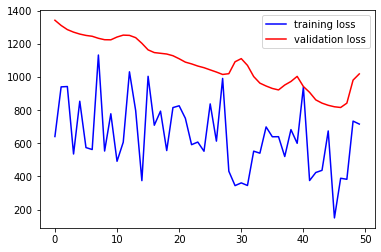

In [36]:
plot_train_history(history)

In [37]:
model.save('my_model.keras') #.keras

In [39]:
loaded_model = tf.keras.models.load_model('my_model.keras')

In [41]:
y_pred = loaded_model.predict(images)

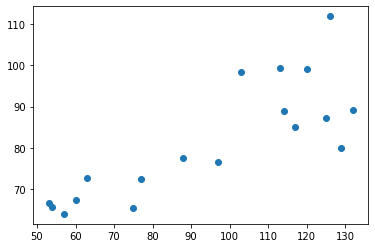

In [42]:
# idealerweise schwanken werte um die Winkelhalbierende
plt.scatter(labels, y_pred)

In [43]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

In [44]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\VWN7QRY\AppData\Local\Temp\tmp5uhdefel\assets


In [45]:
with open("TFLite_Modell.tflite", 'wb') as f:
    f.write(tflite_model)

In [46]:
np.__version__

'1.20.2'